# Notebook 11 — Explainability & Model Interpretation

This notebook explores the inner workings of the validated **Adaptive Financial Transformer (AFT)** model by visualizing:
1. Dynamic **feature-group gates** over time.
2. **Market regime profiling** using K-Means clustering on latent state vectors.
3. **Attention maps** and **financial context matrices** to understand self-attention and dynamic bias.
4. Feature attributions using a custom implementation of **Integrated Gradients (IG)**.

In [1]:
import math
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.cluster import KMeans

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
# Load preprocessed test dataset
X_test = torch.tensor(np.load("pipeline/X_test.npy"), dtype=torch.float32)
y_test = torch.tensor(np.load("pipeline/y_test.npy"), dtype=torch.float32)

with open("pipeline/feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

# Load original master dataset to extract correct dates for alignment
df_master = pd.read_parquet("processed_data/master_dataset.parquet")
test_dates = pd.to_datetime(df_master["Date"].iloc[-len(X_test):].values)

print(f"Test features shape: {X_test.shape} | Test labels shape: {y_test.shape}")
print(f"Aligned test dates range: {test_dates[0].strftime('%Y-%m-%d')} to {test_dates[-1].strftime('%Y-%m-%d')}")

Test features shape: torch.Size([349, 60, 95]) | Test labels shape: torch.Size([349])
Aligned test dates range: 2024-08-02 to 2025-12-22


In [3]:
FEATURE_GROUPS = {
    "price": ["Close","High","Low","Open","Previous_Close","Gap","Price_Change"],
    "returns": ["Daily_Return","Return","Log_Return","ROC_5","ROC_10"],
    "volatility": ["Rolling_Volatility","ATR","Historical_Volatility","Parkinson_Volatility","Garman_Klass","Rolling_STD","Rolling_Variance","Rolling_Return_STD"],
    "trend": ["EMA_9","EMA_21","EMA_50","EMA_200","EMA_12","EMA_26","MACD","Signal","MACD_Histogram"],
    "momentum": ["Momentum_5","Momentum_10","Momentum_20"],
    "volume": ["Volume","Volume_MA_5","Volume_MA_20","Relative_Volume","Volume_Change","Volume_Momentum","OBV","VWAP"],
    "candlestick": ["Body","Upper_Wick","Lower_Wick","Full_Range","Body_Ratio","Upper_Wick_Ratio","Lower_Wick_Ratio","Body_to_Wick","High_Low_Range","Open_Close_Range","True_Range"],
    "statistics": ["Rolling_Mean","Rolling_Min","Rolling_Max","Rolling_Median","Rolling_Skew","Rolling_Kurtosis","Rolling_Zscore","Rolling_Max_Return","Rolling_Min_Return"],
    "lags": ["Close_Lag_1","Return_Lag_1","Volume_Lag_1","Close_Lag_2","Return_Lag_2","Volume_Lag_2","Close_Lag_3","Return_Lag_3","Volume_Lag_3","Close_Lag_5","Return_Lag_5","Volume_Lag_5","Close_Lag_10","Return_Lag_10","Volume_Lag_10"],
    "breakout": ["Rolling_High_5","Rolling_Low_5","Rolling_High_10","Rolling_Low_10","Rolling_High_20","Rolling_Low_20","Distance_From_High_5","Distance_From_Low_5","Distance_From_High_10","Distance_From_Low_10","Distance_From_High_20","Distance_From_Low_20","Range_Position","Breakout_20","Breakdown_20"],
    "calendar": ["Day","Month","Quarter","DayOfWeek","WeekOfYear"]
}

FEATURE_INDICES = {
    group: [feature_columns.index(col) for col in cols]
    for group, cols in FEATURE_GROUPS.items()
}

D_MODEL = 128
NUM_HEADS = 8
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.15
REGIME_DIM = 32
GROUP_HIDDEN_DIM = 64
SEQ_LENGTH = X_test.shape[1]
INPUT_DIM = X_test.shape[2]

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MarketRegimeEncoder(nn.Module):
    def __init__(self, input_dim, feature_groups, hidden_dim=64, regime_dim=32):
        super().__init__()
        self.feature_groups = feature_groups
        self.group_embeddings = nn.ModuleDict({
            group: nn.Sequential(
                nn.Linear(len(indices), hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, regime_dim)
            )
            for group, indices in feature_groups.items()
        })
        self.temporal_score = nn.Linear(regime_dim, 1)
        self.fusion = nn.Sequential(
            nn.Linear(len(feature_groups) * regime_dim, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, regime_dim)
        )
    def forward(self, x):
        group_vectors = []
        for group, indices in self.feature_groups.items():
            group_sequence = x[:, :, indices]
            embedding = self.group_embeddings[group](group_sequence)
            scores = self.temporal_score(embedding)
            weights = torch.softmax(scores, dim=1)
            pooled = (weights * embedding).sum(dim=1)
            group_vectors.append(pooled)
        regime = torch.cat(group_vectors, dim=1)
        return self.fusion(regime)

class AdaptiveGateNetwork(nn.Module):
    def __init__(self, regime_dim, num_groups):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(regime_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, num_groups)
        )
    def forward(self, regime):
        gates = self.network(regime)
        return torch.softmax(gates, dim=-1)

class AdaptiveFinancialContext(nn.Module):
    def __init__(self, d_head, feature_groups):
        super().__init__()
        self.feature_groups = feature_groups
        self.projections = nn.ModuleDict({
            group: nn.Linear(len(indices), d_head)
            for group, indices in feature_groups.items()
        })
    def forward(self, x, gates, use_gating=True):
        contexts = {}
        for i, (group, indices) in enumerate(self.feature_groups.items()):
            features = x[:, :, indices]
            embedding = self.projections[group](features)
            embedding = F.normalize(embedding, p=2, dim=-1)
            similarity = torch.matmul(embedding, embedding.transpose(-2, -1))
            if use_gating:
                contexts[group] = gates[:, i].view(-1, 1, 1) * similarity
            else:
                contexts[group] = (1.0 / len(self.feature_groups)) * similarity
        return contexts

class RelativeTemporalBias(nn.Module):
    def __init__(self, max_length, num_heads):
        super().__init__()
        self.max_length = max_length
        self.bias = nn.Parameter(torch.zeros(num_heads, 2 * max_length - 1))
        nn.init.trunc_normal_(self.bias, std=0.02)
    def forward(self, length):
        position = torch.arange(length, device=self.bias.device)
        relative = position[:, None] - position[None, :]
        relative += self.max_length - 1
        return self.bias[:, relative]

class ModularFinancialAttention(nn.Module):
    def __init__(self, d_head, num_heads, feature_groups, use_financial_context=True):
        super().__init__()
        self.scale = math.sqrt(d_head)
        self.use_financial_context = use_financial_context
        self.num_groups = len(feature_groups)
        
        if use_financial_context:
            self.context = AdaptiveFinancialContext(d_head, feature_groups)
            self.group_weights = nn.Parameter(torch.ones(self.num_groups))
            self.financial_weight = nn.Parameter(torch.tensor(0.5))
            
        self.temporal_bias = RelativeTemporalBias(61, num_heads)  # Set exactly to 61 steps to match baseline checkpoints
        self.temporal_weight = nn.Parameter(torch.tensor(0.5))
    def forward(self, Q, K, V, raw_features, gates, use_gating=True):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        
        if self.use_financial_context:
            contexts = self.context(raw_features, gates, use_gating)
            group_weights = torch.softmax(self.group_weights, dim=0)
            financial_bias = 0
            for i, matrix in enumerate(contexts.values()):
                financial_bias += group_weights[i] * matrix
            financial_bias = financial_bias.unsqueeze(1)
            financial_scale = torch.sigmoid(self.financial_weight)
            scores = scores + financial_scale * financial_bias
            
        temporal_bias = self.temporal_bias(Q.shape[-2]).unsqueeze(0)
        temporal_scale = torch.sigmoid(self.temporal_weight)
        scores = scores + temporal_scale * temporal_bias
        
        weights = torch.softmax(scores, dim=-1)
        return torch.matmul(weights, V), weights

class ModularMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, feature_groups, use_financial_context=True):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.attention = ModularFinancialAttention(self.head_dim, num_heads, feature_groups, use_financial_context)
        self.out_proj = nn.Linear(d_model, d_model)
    def forward(self, x, raw_features, gates, use_gating=True):
        B, L, _ = x.shape
        Q = self.q_proj(x).view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        out, weights = self.attention(Q, K, V, raw_features, gates, use_gating)
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        return self.out_proj(out), weights

class FeedForward(nn.Module):
    def __init__(self, d_model, ff_dim, dropout=0.15):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )
    def forward(self, x):
        return self.network(x)

class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, feature_groups, use_financial_context=True, dropout=0.15):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attention = ModularMultiHeadAttention(d_model, num_heads, feature_groups, use_financial_context)
        self.ffn = FeedForward(d_model, ff_dim, dropout)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, raw_features, gates, use_gating=True):
        attn_out, weights = self.attention(self.norm1(x), raw_features, gates, use_gating)
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x, weights

class AdaptiveFinancialTransformer(nn.Module):
    def __init__(self, input_dim, feature_groups, d_model=128, num_heads=8, ff_dim=256, num_layers=2,
                 use_gating=True, use_regime=True, use_financial_context=True, dropout=0.15):
        super().__init__()
        self.use_gating = use_gating
        self.use_regime = use_regime
        self.use_financial_context = use_financial_context
        self.feature_groups = feature_groups
        
        self.embedding = nn.Linear(input_dim, d_model)
        self.position = PositionalEncoding(d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.dropout = nn.Dropout(dropout)
        
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, ff_dim, feature_groups, use_financial_context, dropout)
            for _ in range(num_layers)
        ])
        
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
        if use_regime:
            self.market_encoder = MarketRegimeEncoder(input_dim, feature_groups)
            if use_gating:
                self.gate_network = AdaptiveGateNetwork(32, len(feature_groups))
    def forward(self, x):
        raw_features = x
        B, L, _ = x.shape
        
        # Gate setup
        if self.use_regime:
            regime = self.market_encoder(raw_features)
            if self.use_gating:
                gates = self.gate_network(regime)
            else:
                gates = torch.ones(B, len(self.feature_groups), device=x.device) / len(self.feature_groups)
        else:
            gates = torch.ones(B, len(self.feature_groups), device=x.device) / len(self.feature_groups)
            regime = None
            
        x = self.embedding(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        
        cls_raw = torch.zeros(B, 1, raw_features.size(-1), device=x.device)
        raw_features = torch.cat([cls_raw, raw_features], dim=1)
        
        x = self.position(x)
        x = self.dropout(x)
        
        attention_maps = []
        for layer in self.layers:
            x, weights = layer(x, raw_features, gates, self.use_gating)
            attention_maps.append(weights)
            
        prediction = self.head(x[:, 0]).squeeze(-1)
        return prediction, attention_maps, regime, gates

In [5]:
model = AdaptiveFinancialTransformer(
    input_dim=INPUT_DIM, feature_groups=FEATURE_INDICES, d_model=D_MODEL, 
    num_heads=NUM_HEADS, ff_dim=FF_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT
).to(DEVICE)

# Restore verified baseline state dictionary
model.load_state_dict(torch.load("models/adaptive_financial_transformer.pth", map_location=DEVICE))
model.eval()
print("Model weights loaded successfully and set to eval mode.")

Model weights loaded successfully and set to eval mode.


Running model on test set to extract gates and regimes...


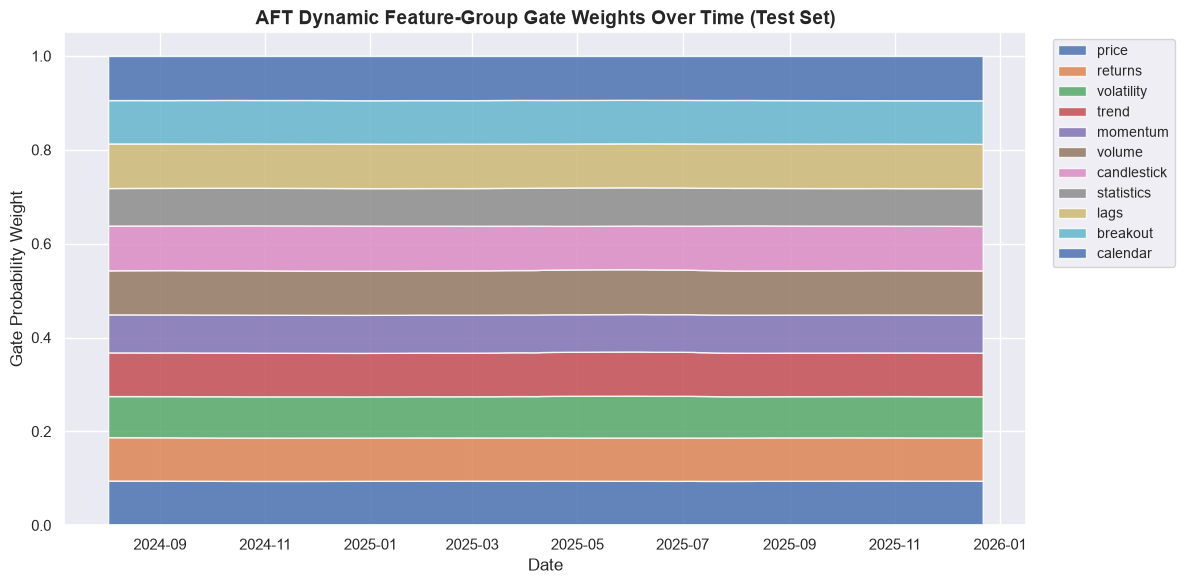

In [6]:
print("Running model on test set to extract gates and regimes...")
with torch.no_grad():
    predictions, attn_maps, regimes, gates = model(X_test.to(DEVICE))
    predictions = predictions.cpu().numpy()
    regimes = regimes.cpu().numpy()
    gates = gates.cpu().numpy()

df_gates = pd.DataFrame(gates, index=test_dates, columns=list(FEATURE_GROUPS.keys()))

# Plot stacked area chart of gate weights
plt.figure(figsize=(12, 6))
plt.stackplot(df_gates.index, [df_gates[col] for col in df_gates.columns], labels=df_gates.columns, alpha=0.85)
plt.title("AFT Dynamic Feature-Group Gate Weights Over Time (Test Set)", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gate Probability Weight", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig("experiments/gate_weights_over_time.png", dpi=300)
plt.show()

Fitting K-Means to profile market regimes...



Average Gate Weights by Market Regime:
         price  returns  volatility   trend  momentum  volume  candlestick  statistics    lags  breakout  calendar
Regime                                                                                                            
0       0.0949   0.0922      0.0878  0.0929    0.0810  0.0942       0.0955      0.0801  0.0946    0.0926    0.0941
1       0.0948   0.0921      0.0890  0.0939    0.0799  0.0954       0.0931      0.0815  0.0938    0.0928    0.0936
2       0.0948   0.0922      0.0882  0.0933    0.0806  0.0947       0.0946      0.0807  0.0942    0.0930    0.0938


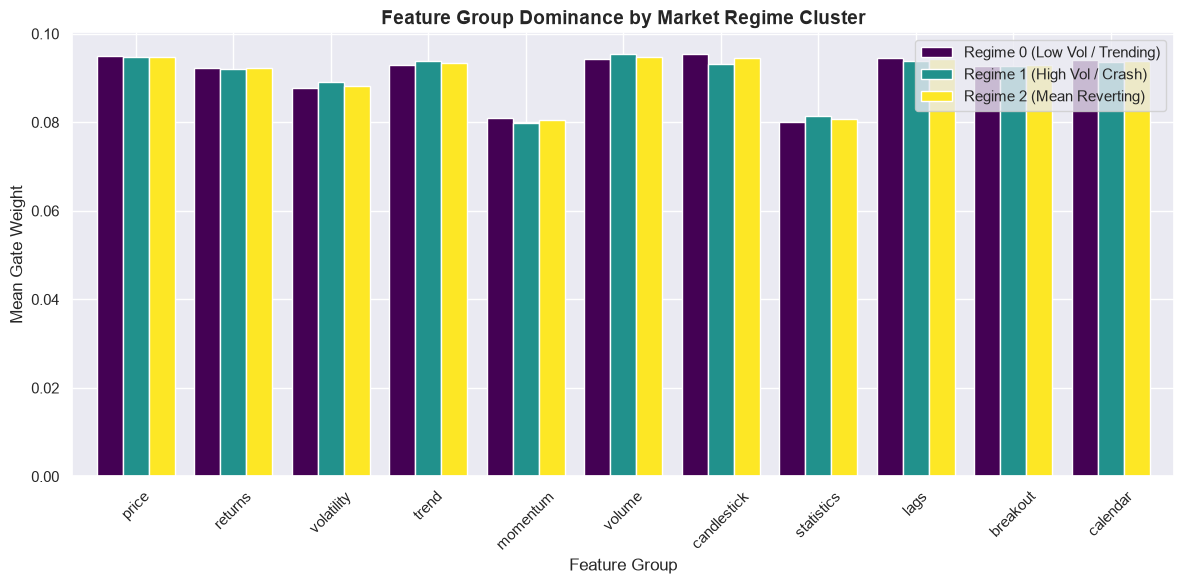

In [7]:
print("Fitting K-Means to profile market regimes...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
regime_labels = kmeans.fit_predict(regimes)

df_gates["Regime"] = regime_labels
profile = df_gates.groupby("Regime").mean()

print("\nAverage Gate Weights by Market Regime:")
print(profile.round(4).to_string())

# Plot grouped bar chart of gate weights per regime
profile.T.plot(kind="bar", figsize=(12, 6), width=0.8, colormap="viridis")
plt.title("Feature Group Dominance by Market Regime Cluster", fontsize=14, fontweight="bold")
plt.xlabel("Feature Group", fontsize=12)
plt.ylabel("Mean Gate Weight", fontsize=12)
plt.xticks(rotation=45)
plt.legend(["Regime 0 (Low Vol / Trending)", "Regime 1 (High Vol / Crash)", "Regime 2 (Mean Reverting)"], loc="upper right")
plt.tight_layout()
plt.savefig("experiments/regime_profile.png", dpi=300)
plt.show()

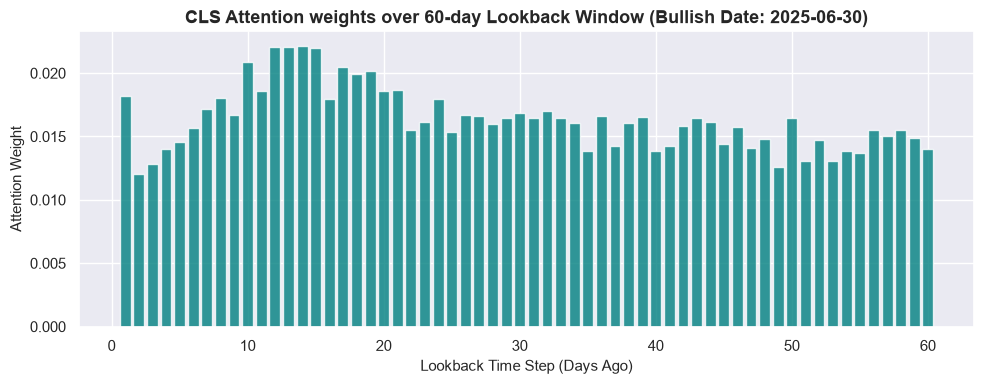

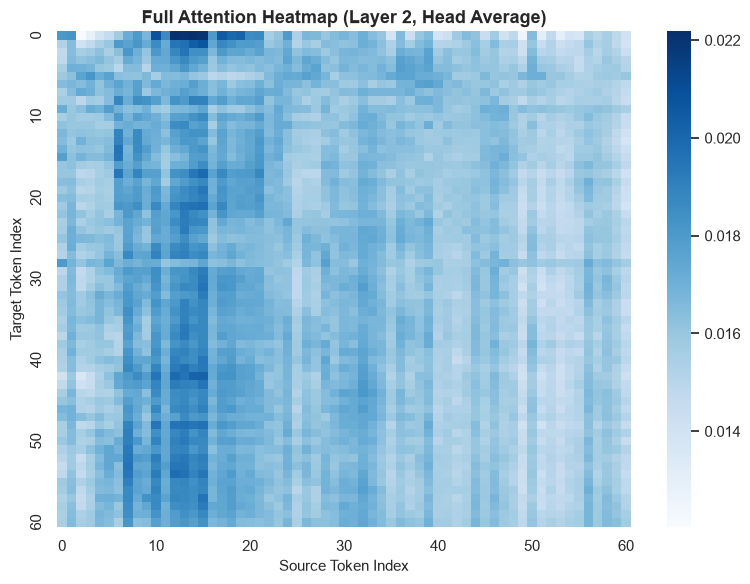

In [8]:
# Select sample with maximum positive prediction (strong bullish signal)
bullish_idx = np.argmax(predictions)

# Extract self-attention maps for this sample from Layer 2 (last layer)
attn_map_sample = attn_maps[1][bullish_idx].cpu().numpy() # shape [8, 61, 61]
avg_attn = attn_map_sample.mean(axis=0) # shape [61, 61]

# Extract CLS attention weights (CLS is at index 0, looking at steps 1 to 60)
cls_attention = avg_attn[0, 1:]

plt.figure(figsize=(10, 4))
plt.bar(range(1, 61), cls_attention, color="teal", alpha=0.8)
plt.title(f"CLS Attention weights over 60-day Lookback Window (Bullish Date: {test_dates[bullish_idx].strftime('%Y-%m-%d')})", fontsize=13, fontweight="bold")
plt.xlabel("Lookback Time Step (Days Ago)", fontsize=11)
plt.ylabel("Attention Weight", fontsize=11)
plt.tight_layout()
plt.savefig("experiments/cls_attention_bullish.png", dpi=300)
plt.show()

# Plot full attention matrix
plt.figure(figsize=(8, 6))
sns.heatmap(avg_attn, cmap="Blues", xticklabels=10, yticklabels=10)
plt.title("Full Attention Heatmap (Layer 2, Head Average)", fontsize=13, fontweight="bold")
plt.xlabel("Source Token Index", fontsize=11)
plt.ylabel("Target Token Index", fontsize=11)
plt.tight_layout()
plt.savefig("experiments/attention_matrix.png", dpi=300)
plt.show()

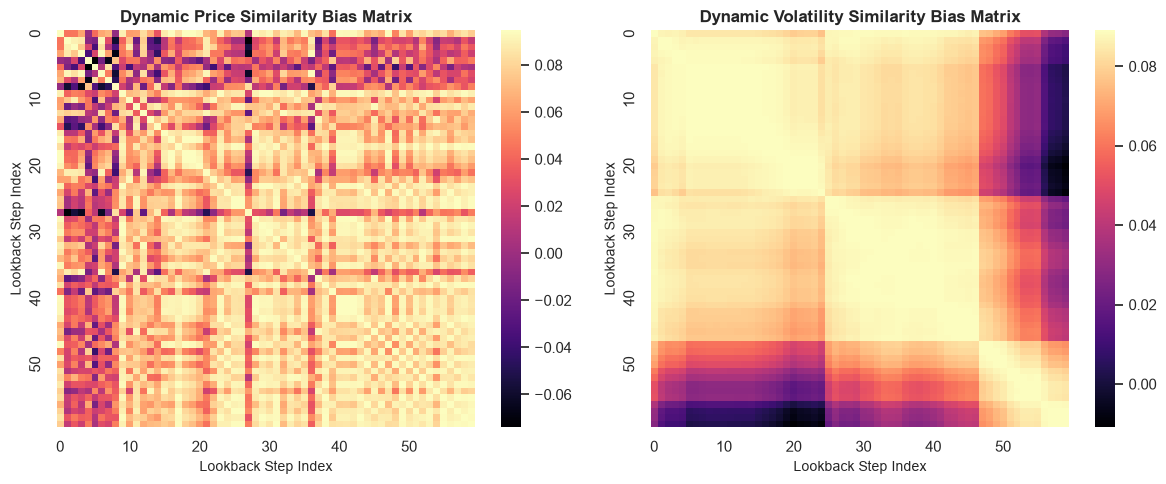

In [9]:
# Extract financial context bias matrices
with torch.no_grad():
    gates_tensor = torch.tensor(gates[bullish_idx:bullish_idx+1]).to(DEVICE)
    x_sample = X_test[bullish_idx:bullish_idx+1].to(DEVICE)
    contexts = model.layers[0].attention.attention.context(x_sample, gates_tensor)
    
    # Visualize similarity context matrices for 'price' group
    price_ctx = contexts["price"][0].cpu().numpy() # shape [60, 60]
    vol_ctx = contexts["volatility"][0].cpu().numpy()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(price_ctx, cmap="magma", xticklabels=10, yticklabels=10)
plt.title("Dynamic Price Similarity Bias Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Lookback Step Index", fontsize=10)
plt.ylabel("Lookback Step Index", fontsize=10)

plt.subplot(1, 2, 2)
sns.heatmap(vol_ctx, cmap="magma", xticklabels=10, yticklabels=10)
plt.title("Dynamic Volatility Similarity Bias Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Lookback Step Index", fontsize=10)
plt.ylabel("Lookback Step Index", fontsize=10)
plt.tight_layout()
plt.savefig("experiments/context_similarity_bias.png", dpi=300)
plt.show()

Computing Integrated Gradients on bullish sample...


D:\HFT\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


C:\Users\User\AppData\Local\Temp\ipykernel_3348\2463281192.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Attribution", y="Feature", data=df_importance, palette="viridis")


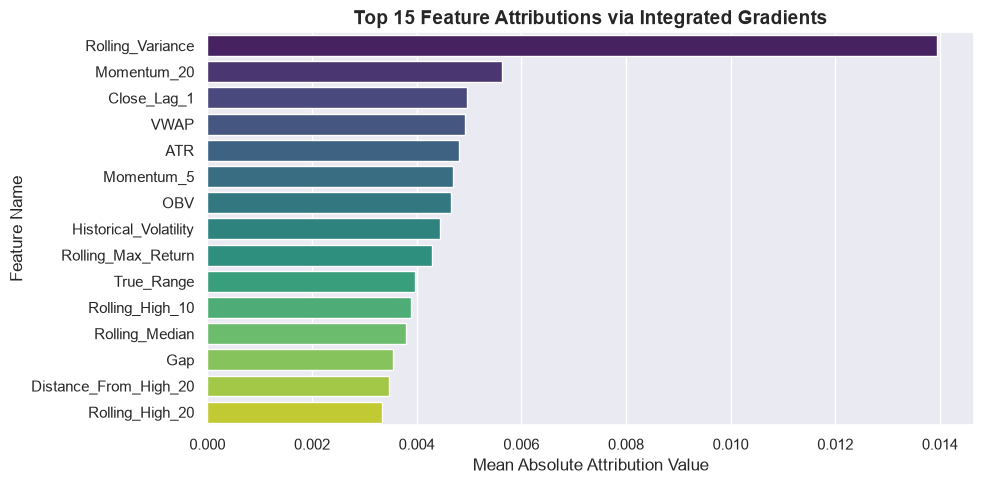

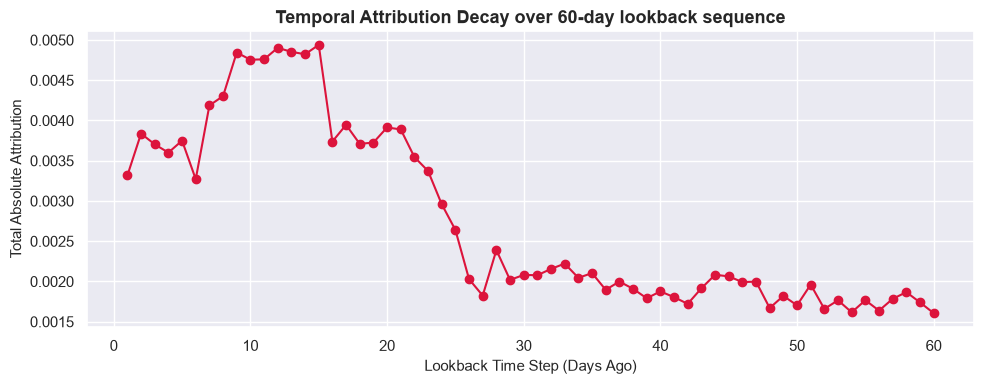

In [10]:
def compute_integrated_gradients(model, x, baseline=None, steps=50):
    model.eval()
    if baseline is None:
        baseline = torch.zeros_like(x)
        
    scaled_inputs = [baseline + (float(i) / steps) * (x - baseline) for i in range(steps + 1)]
    
    grads = []
    for scaled_input in scaled_inputs:
        scaled_input = scaled_input.clone().detach().requires_grad_(True)
        pred, _, _, _ = model(scaled_input)
        loss = pred.sum()
        grad = torch.autograd.grad(loss, scaled_input)[0]
        grads.append(grad.detach())
        
    avg_grads = torch.stack(grads[:-1]).mean(dim=0)
    integrated_grads = (x - baseline) * avg_grads
    return integrated_grads

print("Computing Integrated Gradients on bullish sample...")
x_sample = X_test[bullish_idx:bullish_idx+1]
ig_attributions = compute_integrated_gradients(model, x_sample.to(DEVICE), steps=50)[0].cpu().numpy() # shape [60, 95]

# Sum absolute attributions over the lookback sequence length to get feature importance
feature_importances = np.sum(np.abs(ig_attributions), axis=0)
df_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Attribution": feature_importances
}).sort_values("Attribution", ascending=False).head(15)

# Plot horizontal bar chart of top feature attributions
plt.figure(figsize=(10, 5))
sns.barplot(x="Attribution", y="Feature", data=df_importance, palette="viridis")
plt.title("Top 15 Feature Attributions via Integrated Gradients", fontsize=14, fontweight="bold")
plt.xlabel("Mean Absolute Attribution Value", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.tight_layout()
plt.savefig("experiments/ig_feature_attributions.png", dpi=300)
plt.show()

# Plot temporal attribution decay
temporal_importances = np.sum(np.abs(ig_attributions), axis=1)
plt.figure(figsize=(10, 4))
plt.plot(range(1, 61), temporal_importances, marker="o", color="crimson", linewidth=1.5)
plt.title("Temporal Attribution Decay over 60-day lookback sequence", fontsize=13, fontweight="bold")
plt.xlabel("Lookback Time Step (Days Ago)", fontsize=11)
plt.ylabel("Total Absolute Attribution", fontsize=11)
plt.tight_layout()
plt.savefig("experiments/ig_temporal_decay.png", dpi=300)
plt.show()